In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [63]:
import splat
import re
import io
from contextlib import redirect_stdout


names = [
    "HD 89744B",
    "GJ 1048B",
    "G 196-3B",
    "Gliese 584C",
    "HN Peg B",
    "Gliese 570D",
]
names = names[::-1]
types = []
for n in names:
    sp = splat.getSpectrum(name=n)[0]  # 0番目にSpectrumオブジェクトが入っている
    buf = io.StringIO()
    with redirect_stdout(buf):
        sp.info()

    text = buf.getvalue()

    match = re.search(r"SpeX Classification\s*=\s*([LT]\d+\.\d)", text)
    if match:
        print(match.group(1))  # L1.0
        types.append(match.group(1))

print(types)


returning 1 file

T7.0

returning 1 file

T3.0

returning 1 file

L8.0

returning 2 files

L7.0

returning 1 file

L2.0

returning 1 file

L1.0
['T7.0', 'T3.0', 'L8.0', 'L7.0', 'L2.0', 'L1.0']



returning 1 file


returning 1 file


returning 1 file


returning 2 files


returning 1 file


returning 1 file



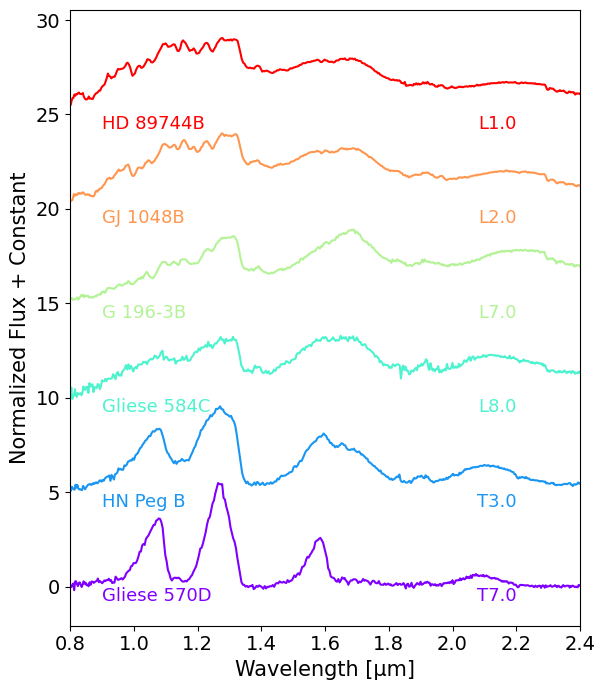

In [66]:
# pipでは古いのでGitHub版推奨（SPLATドキュメント参照）
from tkinter import font
import numpy as np
import matplotlib.pyplot as plt
import splat
specs = []
for n in names:
    try: 
        sp = splat.getSpectrum(name=n)[0]  # 0番目にSpectrumオブジェクトが入っている
        specs.append(sp)
    except:
        print(f"Cannot find {n}")


offset = 5
N = len(specs)  # スペクトル本数
cmap = plt.get_cmap("rainbow")
c = cmap(np.linspace(0, 1, N))

plt.figure(figsize=(6,7))
for i, sp in enumerate(specs):
    wav = sp.wave                # [micron]
    flux = sp.flux/np.nanmedian(sp.flux)
    plt.plot(wav, flux/np.nanstd(flux) + i*offset, lw=1.5, label=sp.name, color=c[i])  # 縦にオフセット
    plt.text(0.9, i*offset-0.5, sp.name, va="center", ha="left", fontsize=13, color=c[i])
    plt.text(2.2, i*offset-0.5, types[i], va="center", ha="right", fontsize=13, color=c[i])
plt.xlim(0.8, 2.4)
plt.xlabel("Wavelength [µm]", fontsize=15)
plt.ylabel("Normalized Flux + Constant", fontsize=15)
plt.tick_params(labelsize=14)
plt.tight_layout()
plt.savefig("bdspectra.png", dpi=300)
plt.show()
